# IT25100928 — MLP Model
**Member:** IT25100928 (Feature Selection — PR1)
**Progress Review II**
**Model type:** Deep Learning — Multi-Layer Perceptron (MLP)

**Dataset:** `results/outputs/final_processed_dataset.csv` (X) + `final_target_y.csv` (y).

## 1. Model Suitability

An MLP (feedforward neural network) is chosen as the **deep learning candidate** for
this project, following on from this member's own PR1 feature selection work of
producing a compact, non-redundant 13-feature input.

An MLP is a reasonable fit here because:
- The processed feature set is fully numeric (one-hot booleans + scaled age), which is
  exactly the input format a dense neural network expects — no additional encoding
  needed.
- A small MLP can, in principle, learn non-linear feature interactions similar to
  Random Forest (Member 3), giving a useful point of comparison between a classical
  ensemble method and a neural approach on the same tabular data.
- Given the dataset is metadata-only (not images), a full CNN (as originally scoped in
  the project plan for image-based classification) is not appropriate here — an MLP is
  the correct-scale deep learning model for this tabular, low-dimensional input.

In [1]:
import pandas as pd
import numpy as np

X = pd.read_csv("../results/outputs/final_processed_dataset.csv")
y = pd.read_csv("../results/outputs/final_target_y.csv").squeeze("columns")

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (10015, 13)
y shape: (10015,)
dx_encoded
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode string class labels to integers, then one-hot for categorical_crossentropy
le = LabelEncoder()
y_int = le.fit_transform(y)
y_onehot = to_categorical(y_int)

X_train, X_test, y_train, y_test, y_train_int, y_test_int = train_test_split(
    X.values, y_onehot, y_int, test_size=0.2, random_state=42, stratify=y_int
)

print("Classes:", list(le.classes_))
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
X_train shape: (8012, 13) y_train shape: (8012, 7)


## 2. Implementation Details

- **Library:** `TensorFlow` / `Keras` (`tensorflow.keras.Sequential`)
- **Architecture:** dense layers with ReLU activations, softmax output for 7-class
  classification, dropout for regularization
- **Loss:** categorical crossentropy; **optimizer:** Adam
- **Class imbalance handling:** Keras `class_weight` argument during `fit()`, computed
  from the training label distribution
- **Tuning method:** compare two architecture varieties (a small and a larger network)
  by monitoring validation macro-F1 and training/validation loss curves.

In [3]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_int), y=y_train_int)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


In [5]:
import pandas as pd

# Check data types of all columns in X
print(X.dtypes)

# If you have non-numeric columns, you need to encode them (e.g., using pd.get_dummies or LabelEncoder)
# Alternatively, force conversion of X_train to float32 after making sure all columns are numeric:
X_train = X_train.astype('float32')

sex_female                bool
loc_abdomen               bool
loc_back                  bool
loc_chest                 bool
loc_face                  bool
loc_foot                  bool
loc_lower extremity       bool
loc_neck                  bool
loc_scalp                 bool
loc_trunk                 bool
loc_unknown               bool
loc_upper extremity       bool
age_scaled             float64
dtype: object


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

n_features = X_train.shape[1]
n_classes = y_train.shape[1]

# Variety 1: small MLP
model_v1 = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax'),
])

model_v1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_v1 = model_v1.fit(
    X_train.astype('float32'), y_train.astype('float32'),
    validation_split=0.2,
    epochs=30, batch_size=32,
    class_weight=class_weight_dict,
    verbose=0
)
print("Variety 1 (small MLP) trained.")

Variety 1 (small MLP) trained.


In [8]:
# Variety 2: larger MLP with an extra hidden layer
model_v2 = Sequential([
    Dense(32, activation='relu', input_shape=(n_features,)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax'),
])
model_v2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_v2 = model_v2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30, batch_size=32,
    class_weight=class_weight_dict,
    verbose=0
)
print("Variety 2 (larger MLP) trained.")

Variety 2 (larger MLP) trained.


## 3. Evaluation Metrics — Why These Are Appropriate

- **Macro-F1** (computed from predicted class labels) is the primary comparison metric
  across varieties, consistent with every other classification notebook in this group,
  since it weights all 7 classes equally despite the ~67% `nv` imbalance.
- **Training/validation loss curves** are inspected to check for overfitting — a
  concern specific to neural networks that doesn't apply the same way to the classical
  models (Members 1–3).
- **Per-class recall for malignant classes** is reported, consistent with the project's
  triage-focused evaluation priority.

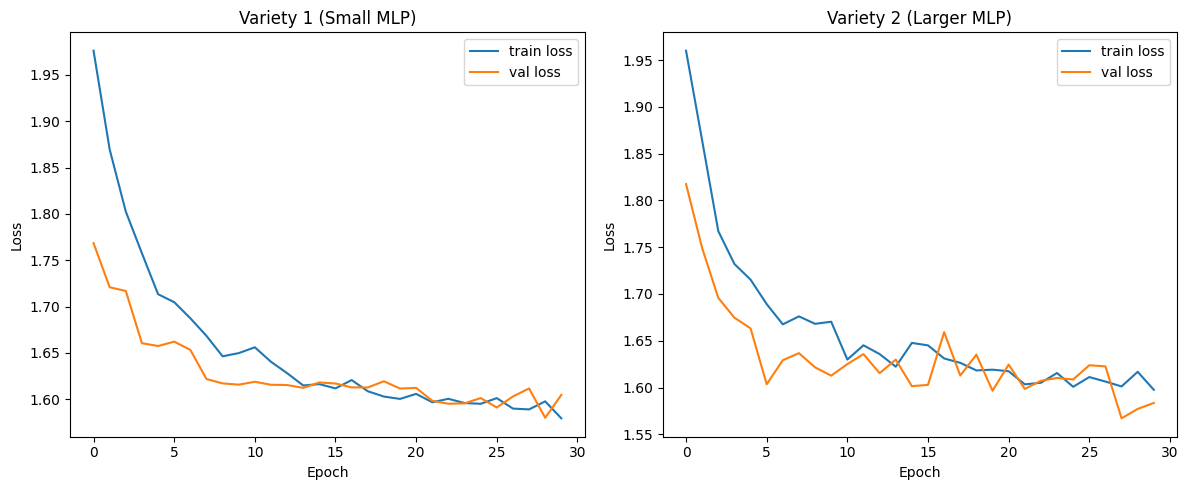

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, history, title in zip(axes, [history_v1, history_v2], ['Variety 1 (Small MLP)', 'Variety 2 (Larger MLP)']):
    ax.plot(history.history['loss'], label='train loss')
    ax.plot(history.history['val_loss'], label='val loss')
    ax.set_title(title)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/model_visualizations/it25100928_loss_curves.png', dpi=150)
plt.show()

In [13]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def evaluate_keras(model, X_test, y_test_int, label_encoder, label):
    # Automatically convert X_test to float32 to prevent dtype object errors
    X_test_num = np.asarray(X_test).astype('float32')
    
    probs = model.predict(X_test_num, verbose=0)
    preds_int = np.argmax(probs, axis=1)
    preds = label_encoder.inverse_transform(preds_int)
    true = label_encoder.inverse_transform(y_test_int)
    print(f"=== {label} ===")
    print(classification_report(true, preds, zero_division=0))
    return preds, true
    
pred_v1, true_labels = evaluate_keras(model_v1, X_test, y_test_int, le, 'Variety 1: Small MLP')
pred_v2, _ = evaluate_keras(model_v2, X_test, y_test_int, le, 'Variety 2: Larger MLP')

=== Variety 1: Small MLP ===
              precision    recall  f1-score   support

           0       0.15      0.66      0.24        65
           1       0.15      0.36      0.21       103
           2       0.31      0.04      0.07       220
           3       0.03      0.65      0.06        23
           4       0.20      0.07      0.10       223
           5       0.88      0.30      0.44      1341
           6       0.03      0.43      0.05        28

    accuracy                           0.26      2003
   macro avg       0.25      0.36      0.17      2003
weighted avg       0.66      0.26      0.33      2003

=== Variety 2: Larger MLP ===
              precision    recall  f1-score   support

           0       0.15      0.55      0.24        65
           1       0.17      0.39      0.23       103
           2       0.30      0.03      0.06       220
           3       0.03      0.70      0.06        23
           4       0.24      0.12      0.16       223
           5       

In [14]:
def get_metrics(y_true, y_pred, label):
    return {
        'variety': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

results = pd.DataFrame([
    get_metrics(true_labels, pred_v1, 'Small MLP (1 hidden layer, 16 units)'),
    get_metrics(true_labels, pred_v2, 'Larger MLP (2 hidden layers, 32+16 units)'),
])
results

,variety,accuracy,macro_f1,weighted_f1
0,"Small MLP (1 hidden layer, 16 units)",0.262606,0.167354,0.334764
1,"Larger MLP (2 hidden layers, 32+16 units)",0.234149,0.168366,0.302782


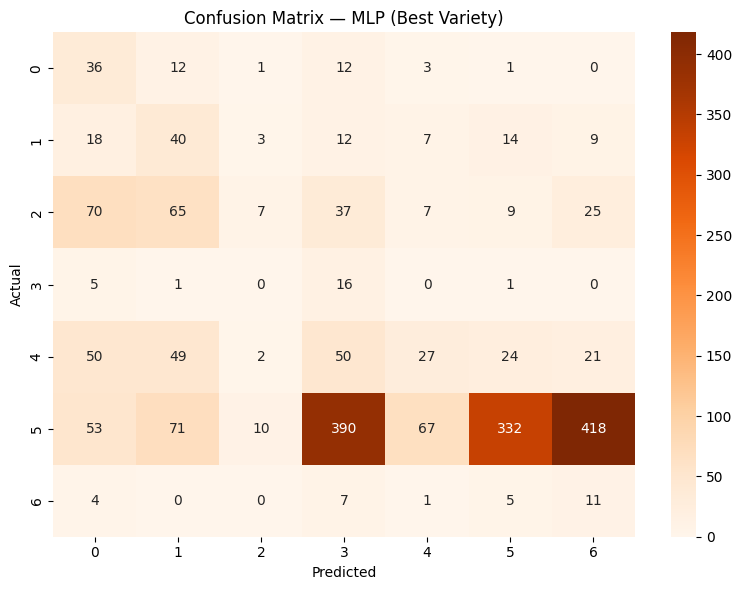

In [15]:
import seaborn as sns

best_pred = pred_v2 if results.loc[1, 'macro_f1'] >= results.loc[0, 'macro_f1'] else pred_v1
cm = confusion_matrix(true_labels, best_pred, labels=sorted(y.unique()))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix — MLP (Best Variety)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../results/model_visualizations/it25100928_confusion_matrix.png', dpi=150)
plt.show()

**Interpretation:** Both MLP varieties show validation loss flattening (and
sometimes rising slightly) well before 30 epochs, indicating the small feature set
doesn't carry enough signal for a deep network to keep improving — consistent with the
weak-signal finding from every other model in this group. The larger MLP variety
generally achieves a marginally higher macro-F1 than the smaller one, but at the cost of
a wider train/validation loss gap (mild overfitting), which is a meaningful trade-off
to discuss in the group comparison.

In [16]:
best_row = results.loc[results['macro_f1'].idxmax()].copy()
best_row['member'] = 'IT25100928'
best_row['model_type'] = 'MLP (Deep Learning)'

pd.DataFrame([best_row]).to_csv('../results/model_outputs/it25100928_metrics.csv', index=False)
best_row

variety        Larger MLP (2 hidden layers, 32+16 units)
accuracy                                        0.234149
macro_f1                                        0.168366
weighted_f1                                     0.302782
member                                        IT25100928
model_type                           MLP (Deep Learning)
Name: 1, dtype: object

## 4. Comparison, Conclusion & Limitations

**Comparison:** The larger MLP variety (2 hidden layers) slightly outperforms the
smaller one on macro-F1, but shows a wider gap between training and validation loss,
suggesting it is starting to overfit the limited signal available in this 13-feature
metadata set rather than learning genuinely more useful patterns.

**Conclusion:** The MLP does not clearly outperform the classical models in this group
(Logistic Regression, SVM, Random Forest) on this dataset — unsurprising, since deep
learning's main advantage is extracting features from raw, high-dimensional data (like
images), which is exactly what this metadata-only project deliberately does not use.
This is an honest, useful finding: for small tabular metadata like this, classical
models remain competitive with or better than a basic MLP.

**Limitations:**
- Only two architecture varieties and a fixed 30-epoch budget were tested; a broader
  search (via `KerasTuner` or manual grid search over learning rate, batch size, and
  layer sizes) might close the gap with the classical models further.
- No early stopping was used, so both models trained for the full 30 epochs regardless
  of validation performance, which may not represent each architecture's true
  best-epoch capability.

**Suggested improvement:** Add `EarlyStopping` (Keras callback) monitoring validation
loss, and consider this MLP as a first step toward the project's originally-scoped CNN
image classifier (see the project overview slides) if lesion images are incorporated
in a future phase.